In [ ]:
# Importing libraries
import pandas as pd
import numpy as np

# Importing dataset (use the correct path to your Google Drive)
fb_complete_data = pd.read_csv("/content/fb_train.csv")

# Printing dataset header
fb_complete_data.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,78.580002,78.930000,77.699997,78.449997,78.449997,18177500
1,2015-01-05,77.980003,79.250000,76.860001,77.190002,77.190002,26452200
2,2015-01-06,77.230003,77.589996,75.360001,76.150002,76.150002,27399300
3,2015-01-07,76.760002,77.360001,75.820000,76.150002,76.150002,22045300
4,2015-01-08,76.739998,78.230003,76.080002,78.180000,78.180000,23961000


In [ ]:
# Filtering 'Open' column
fb_training_processed = fb_complete_data[['Open']].values

# Scaling features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
fb_training_scaled = scaler.fit_transform(fb_training_processed)

len(fb_training_scaled)  # 1257


1257

In [ ]:
# Training features contain data of the last 60 days
# Training labels contain data of the 61st day
fb_training_features = []
fb_training_labels = []

for i in range(60, len(fb_training_scaled)):
    fb_training_features.append(fb_training_scaled[i - 60:i, 0])
    fb_training_labels.append(fb_training_scaled[i, 0])


In [ ]:
fb_training_features = []
fb_training_labels = []

for i in range(60, len(fb_training_scaled)):
    fb_training_features.append(fb_training_scaled[i - 60:i, 0])
    fb_training_labels.append(fb_training_scaled[i, 0])

In [ ]:
# Converting training data to NumPy arrays
X_train = np.array(fb_training_features)
y_train = np.array(fb_training_labels)

# Print the shape of our dataset
print(X_train.shape)
print(y_train.shape)

# Expected output:
# (1197, 60)
# (1197,)

# Converting data into 3D shape for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

(1197, 60)
(1197,)


In [9]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Dropout, LSTM
from tensorflow.keras.models import Model

# Defining the LSTM network
input_layer = Input(shape=(X_train.shape[1], 1))

lstm1 = LSTM(100, activation='relu', return_sequences=True)(input_layer)
do1 = Dropout(0.2)(lstm1)

lstm2 = LSTM(100, activation='relu', return_sequences=True)(do1)
do2 = Dropout(0.2)(lstm2)

lstm3 = LSTM(100, activation='relu', return_sequences=True)(do2)
do3 = Dropout(0.2)(lstm3)

lstm4 = LSTM(100, activation='relu')(do3)
do4 = Dropout(0.2)(lstm4)

output_layer = Dense(1)(do4)

model = Model(input_layer, output_layer)
model.compile(optimizer='adam', loss='mse')

# Summary of the model
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 60, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 100)             │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60, 100)             │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 100)                 │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 282,101 (1.08 MB)

 Trainable params: 282,101 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

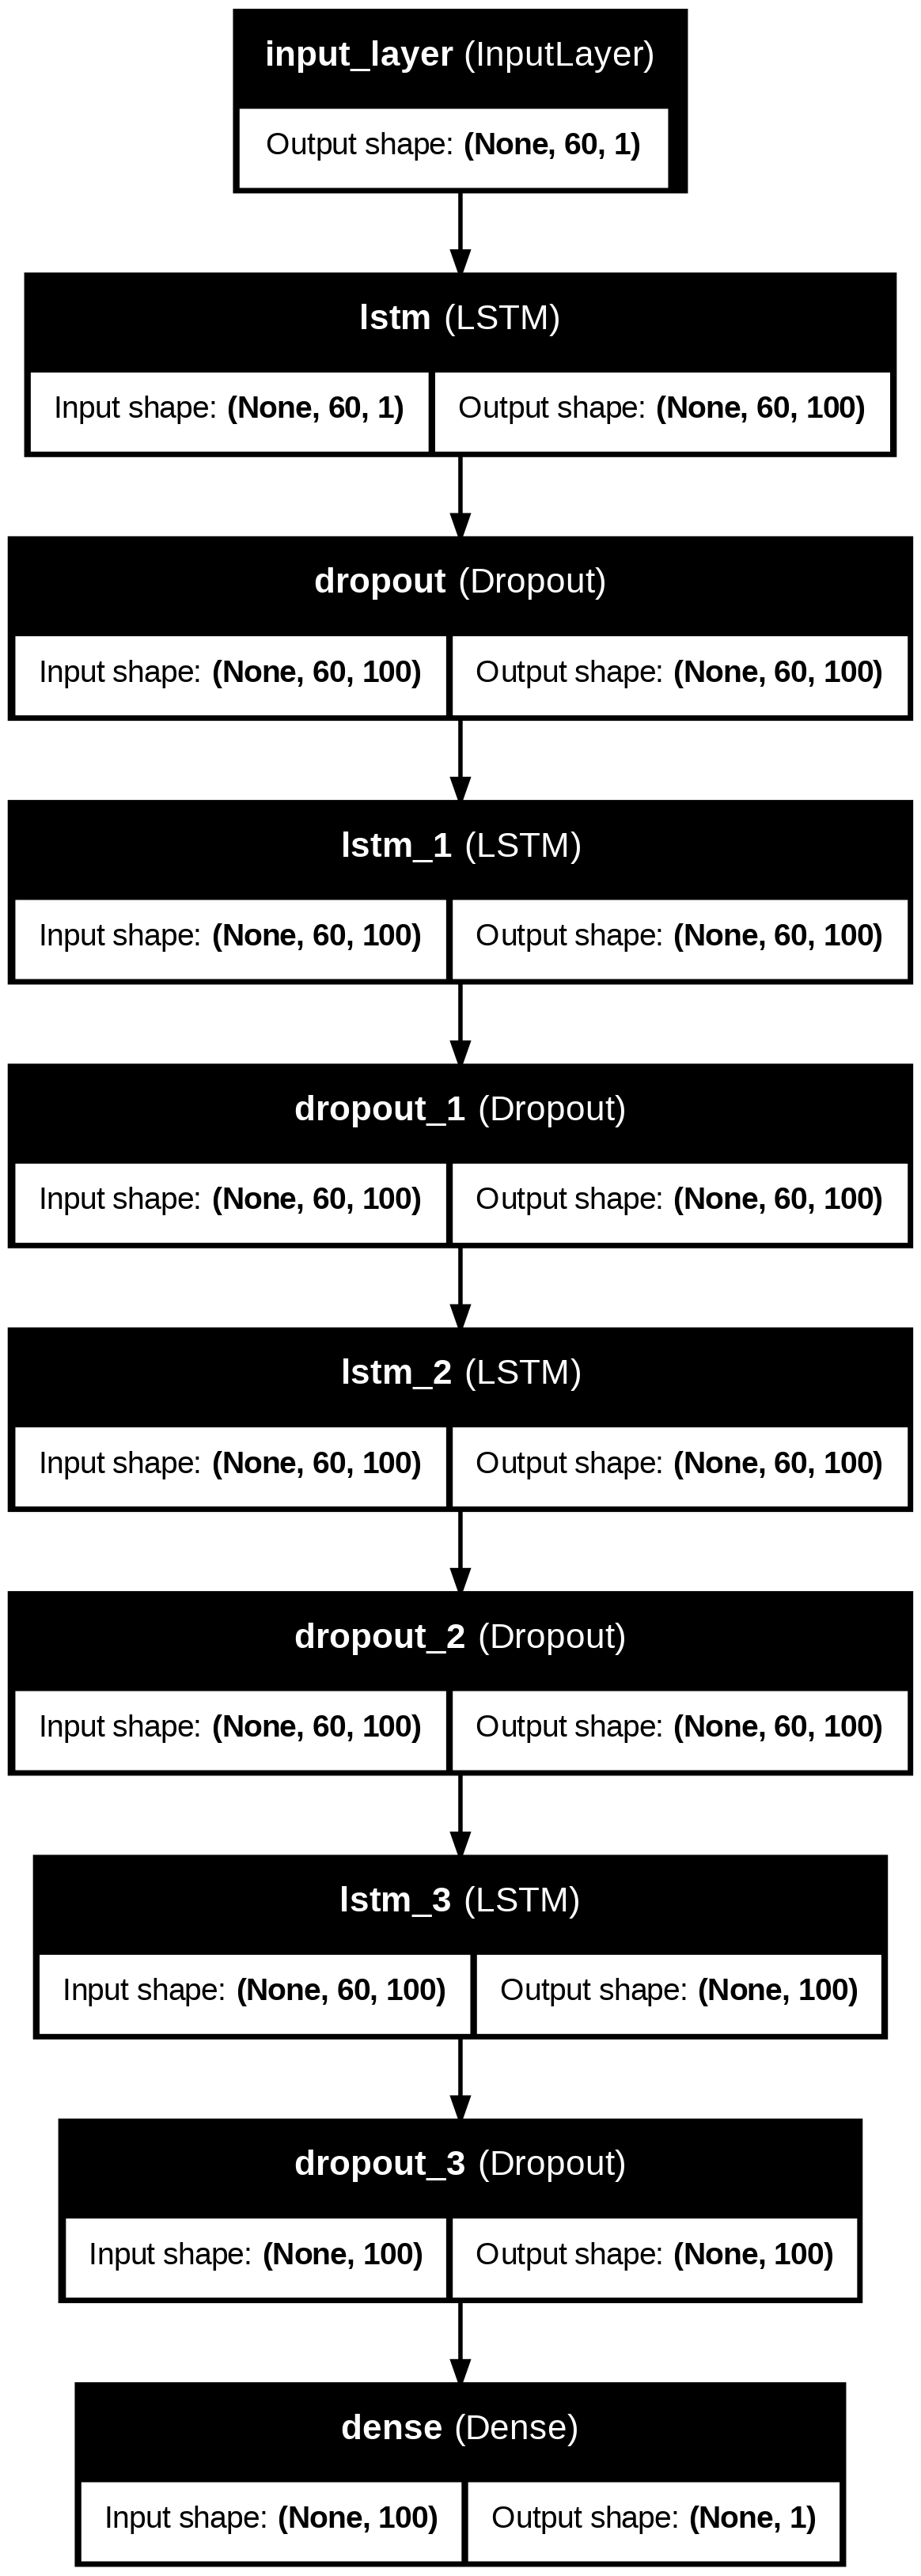

In [11]:
# Plotting model architecture (use your path!)
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model_plot1.png', show_shapes=True, show_layer_names=True)


In [12]:
# Printing dataset shapes
print(X_train.shape)
print(y_train.shape)

# Reshaping y_train
y_train = y_train.reshape(-1, 1)
print(y_train.shape)

# Training the model
model_history = model.fit(X_train, y_train, epochs=100, verbose=1, batch_size=32)


(1197, 60, 1)
(1197,)
(1197, 1)
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.1591
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0094
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0074
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0061
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0067
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0062
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0054
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0050
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0057
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 0.0070
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - loss: 0.0048
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.0047
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - loss: 0.0041
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - loss: 0.0039
Epoch 15/1

In [13]:
# Creating test set (use your path)
fb_testing_complete_data = pd.read_csv("/content/fb_test.csv")
fb_testing_processed = fb_testing_complete_data[['Open']].values

# Concatenating the training and test sets
# We do this to predict the first value in the test set using past 60 days of data
fb_all_data = pd.concat((fb_complete_data['Open'], fb_testing_complete_data['Open']), axis=0)

# Creating final input feature set
test_inputs = fb_all_data[len(fb_all_data) - len(fb_testing_complete_data) - 60:].values
print(test_inputs.shape)  # Expected output: (80,)


(80,)


In [14]:
# Scaling the test data and converting it into a column vector
test_inputs = test_inputs.reshape(-1, 1)
test_inputs = scaler.transform(test_inputs)
print(test_inputs.shape)  # Expected output: (80, 1)

# Creating test features as we did with the training data
fb_test_features = []
for i in range(60, 80):
    fb_test_features.append(test_inputs[i - 60:i, 0])  # Using the past 60 days as input


(80, 1)


In [15]:
# Converting test features into a NumPy array
X_test = np.array(fb_test_features)
print(X_test.shape)  # Expected output: (20, 60)

# Reshaping test data into 3D shape for LSTM model
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(X_test.shape)  # Expected output: (20, 60, 1)


(20, 60)
(20, 60, 1)


In [16]:
# Predicting the stock prices using the trained model
y_pred = model.predict(X_test)
print(y_pred.shape)

# Since we scaled our input features, we need to apply the inverse_transform() method of
# the scaler object on the predicted output to get the original output values.
# Converting scaled data back to original data
y_pred = scaler.inverse_transform(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step
(20, 1)


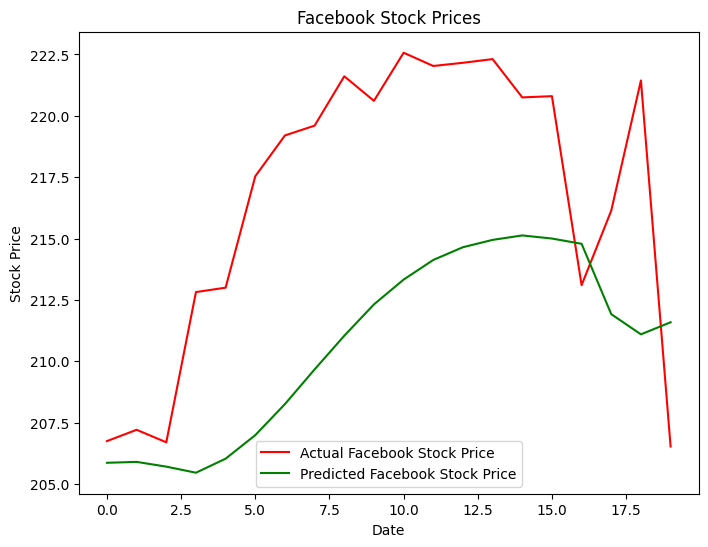

In [18]:
# Plotting original and predicted stock values
plt.figure(figsize=(8,6))
plt.plot(fb_testing_processed, color='red', label='Actual Facebook Stock Price')
plt.plot(y_pred, color='green', label='Predicted Facebook Stock Price')
plt.title('Facebook Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()
